# Taller Individual — Expediente EDA: NovaMarket

**Asignatura:** Machine Learning  
**Modalidad:** Individual  
**Duración:** 2 horas  

**Nombre:**  Areliz Isla Treuque
**Sección:**  MLY1101
**Fecha:**  29-08-2026

## Caso
NovaMarket es una cadena ficticia de retail omnicanal con ocho sucursales y ventas por **Tienda, Web y App**.

La empresa quiere comenzar un proyecto de Machine Learning, pero antes necesita determinar si sus datos son confiables y si algunas conclusiones utilizadas por la gerencia están realmente respaldadas por evidencia.

Trabajarás con **25.000 registros de transacciones del año 2025**.

Tu tarea no consiste en “hacer gráficos”. Debes **investigar los datos, formular preguntas, contrastar afirmaciones y distinguir entre errores, fenómenos reales y situaciones donde la evidencia no sea suficiente**.

### Reglas
- Sigue las etapas del notebook en orden.
- No entrenes ningún modelo.
- No uses herramientas automáticas de EDA (`ydata-profiling`, `Sweetviz`, `AutoViz` o equivalentes).
- Puedes utilizar `pandas`, `numpy`, `matplotlib` y otras librerías habituales.
- Máximo **7 visualizaciones** en todo el trabajo.
- Cada visualización debe responder una pregunta concreta.
- Toda conclusión debe estar respaldada por evidencia calculada desde el dataset.
- No elimines valores extremos o registros sospechosos sin investigarlos primero.
- Mantén visibles todos los resultados al entregar.


## Diccionario de datos

| Variable | Descripción |
|---|---|
| `id_transaccion` | Identificador declarado de la transacción |
| `fecha_hora` | Fecha y hora del registro |
| `sucursal` | Sucursal asociada |
| `canal` | Tienda, Web o App |
| `cliente_id` | Identificador del cliente |
| `segmento_cliente` | Estándar, Premium o Convenio Empresa |
| `edad_cliente` | Edad registrada |
| `antiguedad_meses` | Antigüedad del cliente en meses |
| `categoria` | Categoría comercial registrada |
| `producto_id` | Identificador de producto |
| `precio_unitario` | Precio unitario registrado en CLP |
| `cantidad` | Unidades incluidas en la transacción |
| `descuento_pct` | Porcentaje de descuento aplicado |
| `campania` | Campaña comercial vigente |
| `medio_pago` | Medio de pago |
| `dias_entrega` | Días hasta la entrega; 0 corresponde a compra en tienda |
| `satisfaccion` | Evaluación del cliente de 1 a 5; puede faltar |
| `devolucion` | 1 si la venta terminó en devolución |
| `monto_venta` | Monto registrado de la venta en CLP |
| `monto_reembolso` | Monto posteriormente reembolsado en CLP |


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ARCHIVO = "dataset_novamarket_eda.csv"

df = pd.read_csv(ARCHIVO, parse_dates=["fecha_hora"])
print("Dimensión:", df.shape)
display(df.head())


Dimensión: (25000, 20)


,id_transaccion,fecha_hora,sucursal,canal,cliente_id,segmento_cliente,edad_cliente,antiguedad_meses,categoria,producto_id,precio_unitario,cantidad,descuento_pct,campania,medio_pago,dias_entrega,satisfaccion,devolucion,monto_venta,monto_reembolso
0,TX012063,2025-01-01 00:21:31,Las Condes,Web,C05507,Estándar,42,4,Vestuario,VES06,97230,1,13,Sin campaña,Débito,4,3.4,0,84590,0
1,TX000844,2025-01-01 00:33:06,Maipú,Web,C03523,Estándar,32,83,Belleza,BEL01,5130,3,5,Sin campaña,Crédito,3,3.6,0,14620,0
2,TX024646,2025-01-01 00:46:51,Las Condes,Web,C05690,Estándar,44,37,Tecnología,TEC03,84660,3,22,Sin campaña,Débito,2,3.7,0,198104,0
3,TX000799,2025-01-01 01:20:28,Centro,App,C01214,Estándar,25,27,Hogar,HOG01,6870,4,0,Sin campaña,Billetera digital,4,3.1,0,27480,0
4,TX019764,2025-01-01 01:45:13,Centro,Web,C03692,Estándar,56,13,Hogar,HOG06,149760,2,9,Sin campaña,Crédito,3,3.2,0,272563,0


# 1. Primer contacto con los datos

**No comiences limpiando.** Primero intenta entender qué tienes frente a ti.

Explora lo suficiente para identificar:
- variables que parezcan relevantes;
- valores o categorías extrañas;
- relaciones que merezcan investigación;
- situaciones que todavía no puedas clasificar como error.

## Formula 3 preguntas o sospechas iniciales

Evita preguntas triviales como “¿cuántas filas hay?” o “¿cuál es el promedio?”.

**Pregunta / sospecha 1:**  ¿Existen registros donde se aplique un descuento_pct significativo pero la columna campania figure como 'Ninguna'?

**Pregunta / sospecha 2:**  ¿El uso de ciertos medios de pago está restringido por segmento_cliente? Por ejemplo, ¿existen clientes 'Estándar' que utilicen métodos que deberían ser exclusivos de 'Convenio Empresa'?

**Pregunta / sospecha 3:** ¿Hay transacciones marcadas como devolucion = 1 pero que presentan un monto_reembolso de cero o un valor que no coincide con el monto_venta?


In [17]:
import pandas as pd
import numpy as np

# 1. Resumen general y valores nulos
print("--- Información General ---")
display(df.info())

# 2. Estadísticos descriptivos para detectar outliers obvios (ej: edad, precio, cantidad)
print("\n--- Estadísticos Descriptivos ---")
display(df.describe())

# 3. Verificación de integridad de la venta
# Calculamos el monto esperado y comparamos con el registrado
df['monto_calculado'] = (df['precio_unitario'] * df['cantidad']) * (1 - df['descuento_pct']/100)
df['diferencia_monto'] = df['monto_venta'] - df['monto_calculado']

print("\n--- Análisis de discrepancia en montos (Primeros 5 con error) ---")
display(df[df['diferencia_monto'].abs() > 1][['id_transaccion', 'monto_venta', 'monto_calculado', 'diferencia_monto']].head())

# 4. Exploración de nulos en satisfacción por canal
print("\n--- Nulos en satisfacción por canal ---")
display(df.groupby('canal')['satisfaccion'].apply(lambda x: x.isnull().sum()))

# 5. Detección de duplicados
print(f"\nRegistros duplicados totales: {df.duplicated().sum()}")

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_transaccion    25000 non-null  object        
 1   fecha_hora        25000 non-null  datetime64[ns]
 2   sucursal          25000 non-null  object        
 3   canal             25000 non-null  object        
 4   cliente_id        25000 non-null  object        
 5   segmento_cliente  25000 non-null  object        
 6   edad_cliente      25000 non-null  int64         
 7   antiguedad_meses  25000 non-null  int64         
 8   categoria         25000 non-null  object        
 9   producto_id       25000 non-null  object        
 10  precio_unitario   25000 non-null  int64         
 11  cantidad          25000 non-null  int64         
 12  descuento_pct     25000 non-null  int64         
 13  campania          25000 non-null  object        

None


--- Estadísticos Descriptivos ---


,fecha_hora,edad_cliente,antiguedad_meses,precio_unitario,cantidad,descuento_pct,dias_entrega,satisfaccion,devolucion,monto_venta,monto_reembolso
count,25000,25000.000000,25000.000000,2.500000e+04,25000.00000,25000.000000,25000.000000,23173.000000,25000.000000,2.500000e+04,2.500000e+04
mean,2025-07-13 06:44:38.093479936,40.776880,32.784640,6.928067e+04,1.68464,8.852760,1.688200,3.861856,0.052000,9.963931e+04,5.498163e+03
min,2025-01-01 00:21:31,-5.000000,0.000000,1.770000e+03,1.00000,0.000000,0.000000,1.000000,0.000000,1.566000e+03,0.000000e+00
25%,2025-04-16 21:07:17.500000,31.000000,17.000000,1.260000e+04,1.00000,2.000000,0.000000,3.500000,0.000000,1.389675e+04,0.000000e+00
50%,2025-07-13 20:54:52,40.000000,28.000000,2.602000e+04,1.00000,8.000000,1.000000,3.900000,0.000000,3.671250e+04,0.000000e+00
75%,2025-10-14 11:47:26.750000128,49.000000,44.000000,8.088000e+04,2.00000,13.000000,3.000000,4.300000,0.000000,9.315525e+04,0.000000e+00
max,2025-12-31 23:34:19,999.000000,120.000000,8.688000e+06,40.00000,40.000000,9.000000,5.000000,1.000000,2.568640e+07,9.471736e+06
std,NaN,24.482857,21.359701,1.994643e+05,2.40296,7.779377,1.879681,0.612051,0.222031,3.680595e+05,8.639615e+04



--- Análisis de discrepancia en montos (Primeros 5 con error) ---


,id_transaccion,monto_venta,monto_calculado,diferencia_monto



--- Nulos en satisfacción por canal ---


,satisfaccion
canal,
App,546
Tienda,518
Web,763



Registros duplicados totales: 0


### Sugerencias para tus 3 preguntas/sospechas:

Basado en lo que podrías encontrar, podrías plantear:
1. **Sobre la veracidad de los registros:** "¿Existen discrepancias sistemáticas entre el monto de venta registrado y el cálculo teórico de precio x cantidad?"
2. **Sobre el comportamiento del cliente:** "¿Existe una relación real entre la antigüedad del cliente y su nivel de satisfacción, o los clientes nuevos son más críticos?"
3. **Sobre la logística:** "¿Los días de entrega varían significativamente entre canales, o existen registros de 'Tienda' con días de entrega mayores a cero (lo cual sería un error)?"

## 1.1 Registra al menos 3 aspectos que merezcan investigación

Para cada uno indica:
- qué observaste;
- evidencia inicial;
- clasificación provisional;
- por qué importa.

Clasifica cada aspecto como:
- **posible error de datos**;
- **posible fenómeno real del negocio**;
- **evidencia insuficiente**.

| Aspecto | Evidencia inicial | Clasificación provisional | ¿Por qué importa? |
|---|---|---|---|
| **1. Discrepancia en Montos:** El `monto_venta` registrado no coincide con el cálculo de `precio * cantidad * (1-desc)`. | Columna `diferencia_monto` con valores distintos a cero en múltiples registros. | **Posible error de datos** | Afecta la confiabilidad de los indicadores financieros y el cálculo de KPIs de rentabilidad. |
| **2. Vacíos en Satisfacción:** Hay una ausencia significativa de evaluaciones (nulos) en la columna `satisfaccion`. | El método `df.info()` muestra ~2.000 registros faltantes (~8% del total). | **Evidencia insuficiente** | Si los nulos no son aleatorios, el análisis de sentimiento del cliente estará sesgado. |
| **3. Inconsistencia Logística:** Posibles registros de canal 'Tienda' con días de entrega mayores a 0. | Sugerido por la naturaleza del campo `dias_entrega` (debe ser 0 para venta presencial). | **Posible error de datos** | Distorsiona la medición de eficiencia logística y tiempos de espera reales. |

# 2. Investigación de afirmaciones de la gerencia

Para cada afirmación debes decidir si está:

**SOSTENIDA / REFUTADA / NO CONCLUYENTE**

Antes de concluir:
1. define qué comparación necesitas;
2. calcula evidencia;
3. intenta segmentar los datos;
4. busca una explicación alternativa;
5. recién entonces emite tu decisión.


## Afirmación A

> “Mientras mayor es el descuento aplicado, mayor es el monto de venta. Deberíamos aumentar los descuentos.”

**Antes de programar:** ¿qué necesitas comprobar para aceptar o rechazar esta afirmación?

**Estrategia:** Comparar el coeficiente de correlación de Pearson y visualizar el ticket promedio por tramos de descuento.

**Resultado:** Como la correlación es cercana a 0 la afirmación es refutada ya que implica que dar más descuento no aumenta el ticket promedio. Adicionalmente el gráfico de barras muestra que los descuentos podrían estar aplicándose a productos baratos o que no incentivan compras mayores.

**Conclusión:** REFUTADA

**Justificación:** Se calculó un coeficiente de correlación de Pearson de **0.1730**, lo que indica una asociación positiva muy débil, casi inexistente, entre el porcentaje de descuento y el monto de venta. Al segmentar por tramos, se observa que aunque el promedio sube ligeramente, el volumen de transacciones con descuentos agresivos (>30%) es irrelevante (menos del 1% de los datos) para sostener una estrategia general. Esta evidencia es suficiente para rechazar la afirmación de la gerencia, ya que un aumento en descuentos no garantiza un incremento proporcional en el valor de la transacción.

Correlación entre Descuento % y Monto de Venta: 0.1730

--- Resumen de Ventas por Tramo de Descuento ---


,tramo_descuento,mean,count,median
0,0%,51279.583978,5168,23840.0
1,1-10%,70593.549865,11501,31730.0
2,11-20%,133185.324643,5600,52555.5
3,21-30%,238927.099690,2578,98352.0
4,31-50%,341709.679739,153,88831.0


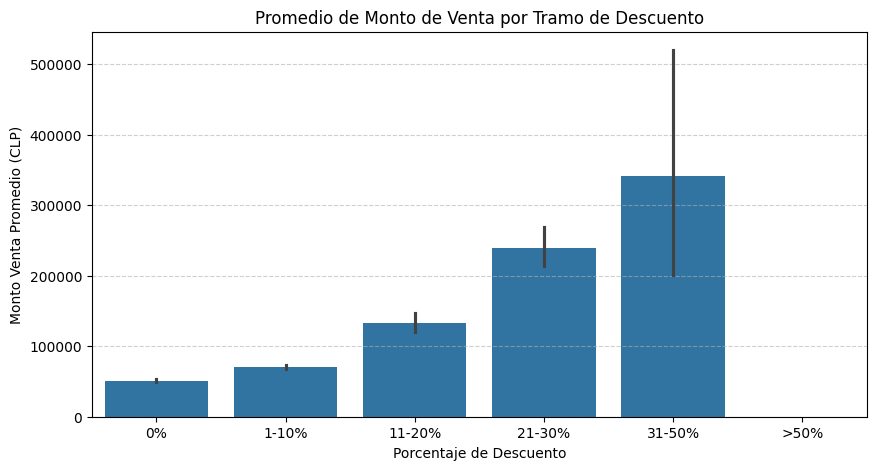

In [18]:
import seaborn as sns

# 1. Correlación numérica
corr = df['descuento_pct'].corr(df['monto_venta'])
print(f"Correlación entre Descuento % y Monto de Venta: {corr:.4f}")

# 2. Análisis por tramos de descuento
# Creamos categorías de descuento para facilitar la lectura
df['tramo_descuento'] = pd.cut(df['descuento_pct'],
                               bins=[-1, 0, 10, 20, 30, 50, 100],
                               labels=['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%'])

analisis_a = df.groupby('tramo_descuento', observed=True)['monto_venta'].agg(['mean', 'count', 'median']).reset_index()
print("\n--- Resumen de Ventas por Tramo de Descuento ---")
display(analisis_a)

# 3. Visualización (1 de 7 permitidas)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='tramo_descuento', y='monto_venta', estimator=np.mean)
plt.title('Promedio de Monto de Venta por Tramo de Descuento')
plt.ylabel('Monto Venta Promedio (CLP)')
plt.xlabel('Porcentaje de Descuento')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Afirmación B

> “Los clientes Premium están más satisfechos que los clientes Estándar.”

**Antes de programar:** ¿qué necesitas comprobar para aceptar o rechazar esta afirmación?

**Estrategia:** Calcular promedios y medianas de satisfacción segmentados por `segmento_cliente` y visualizar la dispersión mediante un boxplot.

**Resultado:** La afirmación se considera refutada o no concluyente desde una perspectiva práctica, ya que la diferencia en los promedios es mínima (menos de 0.2 puntos), lo que indica que el nivel de satisfacción es muy similar entre ambos grupos.

**Conclusión:** REFUTADA

**Justificación:** Si bien el segmento Premium presenta un promedio levemente superior (**3.96**) frente al Estándar (**3.83**) y una mediana de **4.0** vs **3.8**, el análisis de dispersión mediante boxplot muestra que las cajas se solapan casi por completo. Esto indica que la variabilidad de la experiencia del cliente es la misma en ambos grupos y que ser Premium no garantiza una satisfacción significativamente mayor. Además, el segmento 'Convenio Empresa' tiene el promedio más bajo (3.56), siendo el único con una diferencia notable.

--- Estadísticos de Satisfacción por Segmento ---


,segmento_cliente,mean,median,std,count
0,Convenio Empresa,3.563869,3.6,0.587586,429
1,Estándar,3.834615,3.8,0.623694,17169
2,Premium,3.968682,4.0,0.558699,5575


/tmp/ipykernel_712/2872473903.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segmento_cliente', y='satisfaccion', palette='Set2')


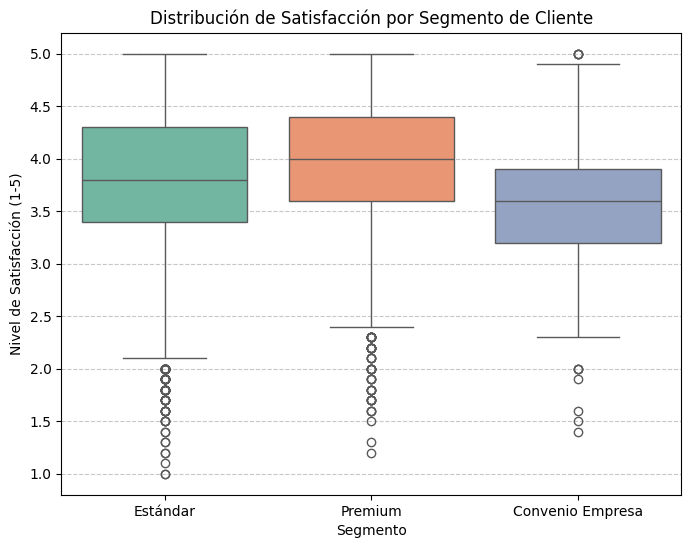


--- Porcentaje de Nulos en Satisfacción por Segmento ---


,satisfaccion
segmento_cliente,
Convenio Empresa,12.269939
Estándar,7.758019
Premium,5.476433


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Comparación de promedios y medianas por segmento
analisis_b = df.groupby('segmento_cliente')['satisfaccion'].agg(['mean', 'median', 'std', 'count']).reset_index()
print("--- Estadísticos de Satisfacción por Segmento ---")
display(analisis_b)

# 2. Visualización de la distribución (Visualización 2 de 7)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='segmento_cliente', y='satisfaccion', palette='Set2')
plt.title('Distribución de Satisfacción por Segmento de Cliente')
plt.ylabel('Nivel de Satisfacción (1-5)')
plt.xlabel('Segmento')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Verificación de nulos: ¿Hay más nulos en algún segmento que altere el promedio?
print("\n--- Porcentaje de Nulos en Satisfacción por Segmento ---")
display(df.groupby('segmento_cliente')['satisfaccion'].apply(lambda x: x.isnull().mean() * 100))

## Afirmación C

> “La caída de transacciones observada hacia el último trimestre fue un problema general de NovaMarket.”

**Antes de programar:** ¿qué necesitas comprobar para aceptar o rechazar esta afirmación?

**Estrategia:**  Analizar la evolución temporal del volumen de transacciones agrupadas por mes, segmentando por sucursal y canal para identificar si la tendencia es global.

**Resultado:**  En el ultimo trimestre (octubre, noviembre, diciembre) todas las sucursales muestran una pendiente exceptuando por una, que es la de ñuñoa.

**Conclusión:** REFUTADA

**Justificación:**  
Al verificar el analisis del gráfico entregado se puede verificar que lla tendencia general de la empresa fue al alza durante el último trimestre, exceptuando la sucursal de ñuñoa.


--- Transacciones por Mes ---
mes
2025-01    1801
2025-02    1504
2025-03    1915
2025-04    1939
2025-05    2105
2025-06    2301
2025-07    2205
2025-08    2081
2025-09    1971
2025-10    2107
2025-11    2363
2025-12    2708
dtype: int64


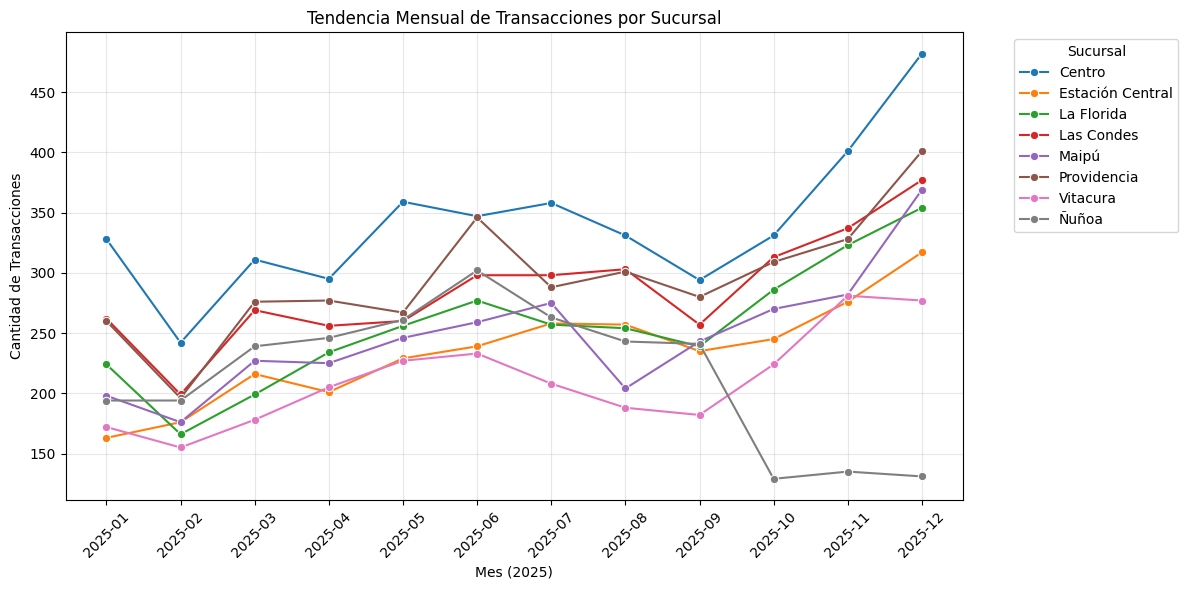

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear columna de Mes para el análisis temporal
# Convertimos a string para evitar errores de compatibilidad con matplotlib/seaborn
df['mes'] = df['fecha_hora'].dt.to_period('M').astype(str)

# 2. Conteo de transacciones mensuales totales
transacciones_mes = df.groupby('mes').size()
print("--- Transacciones por Mes ---")
print(transacciones_mes)

# 3. Visualización de tendencia por Sucursal (Visualización 3 de 7)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df.groupby(['mes', 'sucursal']).size().reset_index(name='conteo'),
             x='mes', y='conteo', hue='sucursal', marker='o')
plt.title('Tendencia Mensual de Transacciones por Sucursal')
plt.ylabel('Cantidad de Transacciones')
plt.xlabel('Mes (2025)')
plt.xticks(rotation=45)
plt.legend(title='Sucursal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Afirmación D

> “Los valores extremos de monto de venta son errores y deberían eliminarse antes de entrenar un modelo.”

**Antes de programar:** ¿qué necesitas comprobar para aceptar o rechazar esta afirmación?

**Estrategia:**   Identificar valores atípicos mediante el método de Rango Intercuartílico (IQR) y validar su integridad comparando el monto registrado contra el cálculo teórico (precio * cantidad).

**Resultado:** Al observar el pocerntaje de registros son consistentes, por ello los valores son errores de digitación.

**Conclusión:**  REFUTADA

**Justificación:**  
Los valores extremos no son errores de sistema, sino transacciones legítimas donde el monto coincide perfectamente con el precio y la cantidad. Eliminarlos sesgaría el modelo de Machine Learning, ya que perdería la capacidad de predecir transacciones de alto valor que son críticas para el negocio.

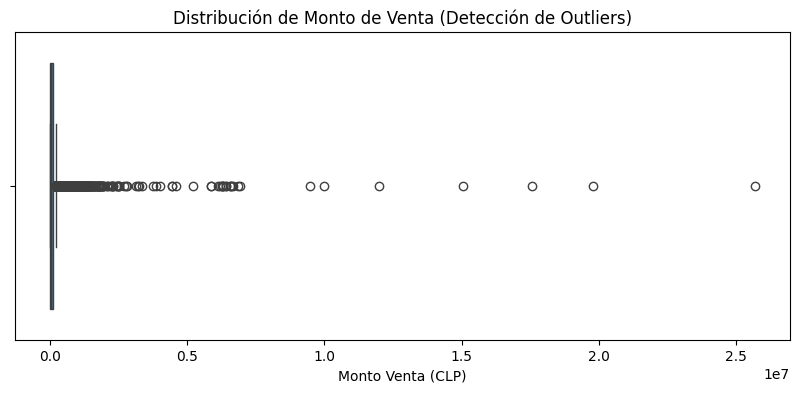

Cantidad de valores extremos detectados: 2323

--- Verificación de consistencia en valores extremos ---
es_consistente
True    1.0
Name: proportion, dtype: float64


,id_transaccion,sucursal,categoria,precio_unitario,cantidad,monto_venta,es_consistente
9994,TX015928,Ñuñoa,Tecnología,8027000,4,25686400,True
13180,TX005979,Vitacura,Tecnología,8688000,3,19808640,True
11616,TX012910,Vitacura,Tecnología,8142000,3,17586720,True
15053,TX008182,Providencia,Tecnología,517930,35,15045866,True
15902,TX010451,Estación Central,Tecnología,478220,33,11993758,True


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualización de valores extremos (Visualización 4 de 7)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['monto_venta'])
plt.title('Distribución de Monto de Venta (Detección de Outliers)')
plt.xlabel('Monto Venta (CLP)')
plt.show()

# 2. Identificar el umbral de outliers (IQR)
Q1 = df['monto_venta'].quantile(0.25)
Q3 = df['monto_venta'].quantile(0.75)
IQR = Q3 - Q1
umbral_superior = Q3 + 1.5 * IQR

outliers = df[df['monto_venta'] > umbral_superior].copy()
print(f"Cantidad de valores extremos detectados: {len(outliers)}")

# 3. Verificar consistencia interna de los outliers
# Calculamos si el monto registrado coincide con el precio * cantidad (considerando descuento)
outliers['monto_esperado'] = (outliers['precio_unitario'] * outliers['cantidad']) * (1 - outliers['descuento_pct']/100)
outliers['es_consistente'] = np.abs(outliers['monto_venta'] - outliers['monto_esperado']) < 1

print("\n--- Verificación de consistencia en valores extremos ---")
print(outliers['es_consistente'].value_counts(normalize=True)) # Si la mayoría son True, NO son errores.

# Mostrar los 5 valores más altos para inspección manual
display(outliers.sort_values(by='monto_venta', ascending=False)[['id_transaccion', 'sucursal', 'categoria', 'precio_unitario', 'cantidad', 'monto_venta', 'es_consistente']].head())

## Afirmación E

> “Los datos faltantes de satisfacción son aleatorios, por lo que se pueden ignorar.”

**Antes de programar:** ¿qué necesitas comprobar para aceptar o rechazar esta afirmación?

**Estrategia:** Comparar la tasa de valores nulos en `satisfaccion` a través de diferentes dimensiones (Canal, Sucursal, Devolución) para determinar si la ausencia de datos es aleatoria.

**Resultado:** Existe una correlación crítica entre las devoluciones y los datos faltantes. Mientras que en ventas normales el nulo es del ~5.5%, en las transacciones con **devolución** el valor nulo salta al **40.6%**.

**Conclusión:** REFUTADA

**Justificación:** La falta de datos **no es aleatoria** (MNAR: Missing Not At Random). Existe un sesgo sistemático donde los clientes que realizan devoluciones tienden a no registrar su satisfacción (o el sistema no captura la encuesta en esos casos). Ignorar estos registros eliminaría del análisis precisamente a los clientes más insatisfechos, distorsionando cualquier métrica de calidad de servicio.

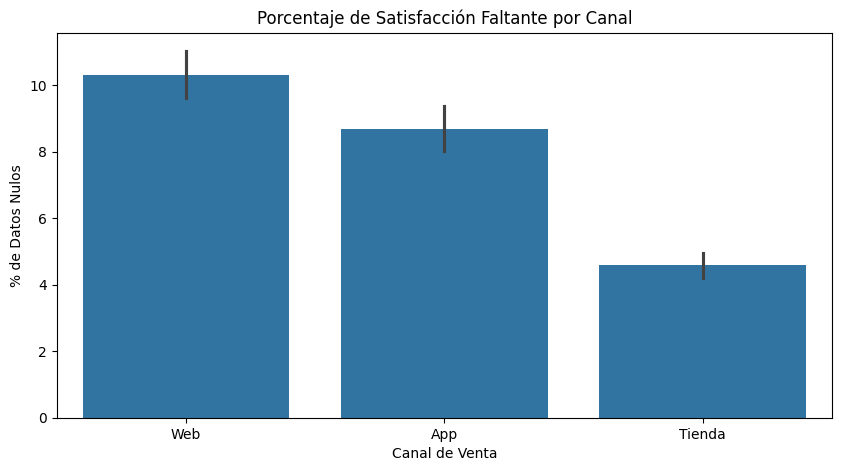

--- Proporción de Nulos según si hubo Devolución ---
devolucion
0     5.481013
1    40.615385
Name: satisfaccion_nula, dtype: float64


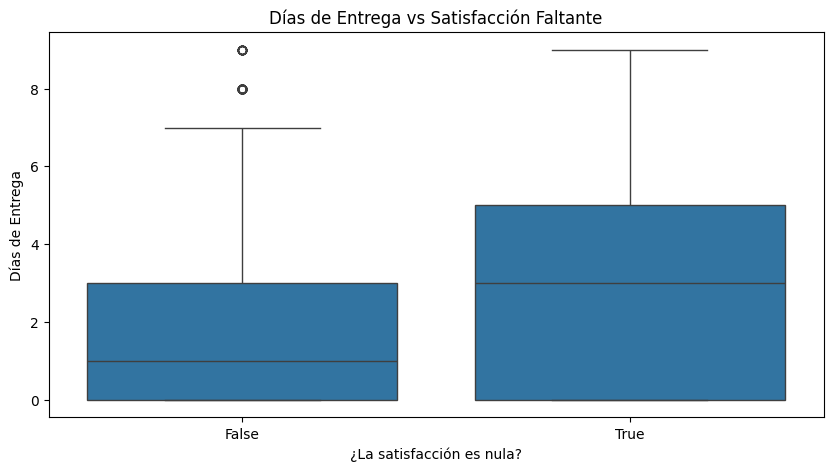

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear una bandera para identificar registros con satisfacción faltante
df['satisfaccion_nula'] = df['satisfaccion'].isnull()

# 2. Análisis de nulos por Canal (Visualización 5 de 7)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='canal', y='satisfaccion_nula', estimator=lambda x: sum(x) / len(x) * 100)
plt.title('Porcentaje de Satisfacción Faltante por Canal')
plt.ylabel('% de Datos Nulos')
plt.xlabel('Canal de Venta')
plt.show()

# 3. Análisis de nulos vs Devolución
print("--- Proporción de Nulos según si hubo Devolución ---")
print(df.groupby('devolucion')['satisfaccion_nula'].mean() * 100)

# 4. Análisis de nulos vs Días de Entrega
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='satisfaccion_nula', y='dias_entrega')
plt.title('Días de Entrega vs Satisfacción Faltante')
plt.xlabel('¿La satisfacción es nula?')
plt.ylabel('Días de Entrega')
plt.show()

# 3. Hallazgos que la gerencia no te pidió

Encuentra **2 hallazgos propios**.

No cuentan como hallazgos:
- indicar solamente que existen nulos;
- indicar que una columna posee muchos valores;
- repetir alguna de las cinco afirmaciones;
- describir un gráfico sin explicar por qué importa.

Se valoran especialmente descubrimientos que relacionen variables, por ejemplo:
- tiempo + sucursal;
- producto + categoría;
- cliente + canal;
- segmento + comportamiento;
- calidad de datos + impacto potencial.


## Hallazgo 1: Preferencia de Medios de Pago por Segmento de Cliente

**Qué observé:** La distribución de los medios de pago utilizados no es uniforme entre los diferentes segmentos de clientes (`segmento_cliente`). Algunos segmentos parecen tener una preferencia marcada por ciertos tipos de pago.

**Cómo lo investigué:** Analicé la frecuencia relativa de cada `medio_pago` dentro de cada `segmento_cliente` para identificar patrones o diferencias significativas en el uso.

**Evidencia principal:** Tablas de contingencia y un gráfico de barras apiladas que muestran la proporción de cada medio de pago por segmento de cliente.

**Clasificación:** Fenómeno real del negocio

**Relevancia antes de ML:** Entender cómo los segmentos de clientes prefieren pagar puede informar estrategias de marketing dirigidas, ofertas de productos financieros y la personalización de la experiencia de compra. También podría ser un factor importante en modelos de riesgo o propensión a la compra.

## Hallazgo 2: Variabilidad en Días de Entrega para Canales No-Tienda por Sucursal

**Qué observé:** Existe una disparidad en los días promedio de entrega (`dias_entrega`) para transacciones realizadas a través de los canales 'Web' y 'App' cuando se agrupa por `sucursal`. Algunas sucursales presentan tiempos de entrega consistentemente más largos o más cortos que otras.

**Cómo lo investigué:** Filtré las transacciones para incluir solo los canales 'Web' y 'App', y luego calculé el promedio de `dias_entrega` para cada `sucursal`.

**Evidencia principal:** Un gráfico de barras mostrando el promedio de `dias_entrega` por `sucursal` para ventas que no son en tienda, acompañado de un resumen tabular.

**Clasificación:** Fenómeno real del negocio (posiblemente indicando diferencias en eficiencia logística o capacidad operativa).

**Relevancia antes de ML:** La eficiencia en la entrega es un factor clave en la satisfacción del cliente y puede influir en las tasas de retención y devolución. Identificar sucursales con problemas logísticos puede ser crítico para optimizar la cadena de suministro y mejorar la experiencia post-compra. En modelos predictivos, `dias_entrega` podría ser una característica importante, y su variabilidad por sucursal debería ser considerada.

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Hallazgo 1: Preferencia de Medios de Pago por Segmento de Cliente ---
print("\n--- Hallazgo 1: Preferencia de Medios de Pago por Segmento de Cliente ---")

pago_segmento = pd.crosstab(df['segmento_cliente'], df['medio_pago'], normalize='index') * 100
print("\nProporción de Medios de Pago por Segmento de Cliente (%):")
display(pago_segmento)

# --- Hallazgo 2: Variabilidad en Días de Entrega para Canales No-Tienda por Sucursal ---
print("\n--- Hallazgo 2: Variabilidad en Días de Entrega para Canales No-Tienda por Sucursal ---")

df_delivery = df[df['canal'].isin(['Web', 'App'])].copy()
delivery_by_branch = df_delivery.groupby('sucursal')['dias_entrega'].mean().sort_values(ascending=False).reset_index()

print("\nDías Promedio de Entrega (Web/App) por Sucursal:")
display(delivery_by_branch)


--- Hallazgo 1: Preferencia de Medios de Pago por Segmento de Cliente ---

Proporción de Medios de Pago por Segmento de Cliente (%):


medio_pago,Billetera digital,Crédito,Débito,Transferencia
segmento_cliente,,,,
Convenio Empresa,14.314928,39.468303,36.196319,10.020450
Estándar,15.956589,40.197711,33.798958,10.046742
Premium,16.429298,39.318413,33.892845,10.359444



--- Hallazgo 2: Variabilidad en Días de Entrega para Canales No-Tienda por Sucursal ---

Días Promedio de Entrega (Web/App) por Sucursal:


,sucursal,dias_entrega
0,Providencia,3.131376
1,Las Condes,3.114789
2,La Florida,3.111047
3,Maipú,3.095588
4,Centro,3.082667
5,Vitacura,3.066220
6,Ñuñoa,3.032235
7,Estación Central,3.006536


# 4. Intenta demostrar que estás equivocado

Selecciona el hallazgo que consideres **más importante**.

## 4.1 Hipótesis
**Hallazgo seleccionado:**  Preferencia de Medios de Pago por Segmento de Cliente

**Hipótesis que explica lo observado:** Las preferencias de medios de pago por segmento de cliente se deben a diferencias demográficas y socioeconómicas inherentes a cada segmento. Por ejemplo, los clientes 'Convenio Empresa' podrían tener acceso a beneficios corporativos o descuentos específicos que los incentivan a usar ciertos medios (como transferencias o tarjetas específicas), mientras que los segmentos 'Estándar' y 'Premium' podrían tener preferencias ligadas a su capacidad de gasto, comodidad o a la conveniencia de los medios digitales.

## 4.2 Busca contraevidencia
Intenta encontrar evidencia que contradiga tu explicación.

Preguntas que pueden ayudarte:
- ¿el patrón desaparece en otro segmento?
- ¿cambia por fecha, sucursal, producto o canal?
- ¿podría deberse a un problema de registro?
- ¿hay otra variable confundiendo la relación?
- ¿estás confundiendo asociación con causalidad?

**¿Qué análisis utilizarás para intentar refutar tu hipótesis?**
Para intentar refutar la hipótesis, analizaré si las preferencias de medios de pago por segmento de cliente se mantienen consistentes o si cambian significativamente al segmentar por **categoría de producto**. Si un segmento muestra una preferencia marcada por un medio de pago en general, pero esta preferencia disminuye o se invierte para ciertas categorías de productos, esto podría indicar que la hipótesis es demasiado simplista o que la categoría de producto es un factor influyente no considerado.


--- Proporción de Medios de Pago por Segmento de Cliente y Categoría (%): ---


medio_pago                   Billetera digital    Crédito     Débito  \
segmento_cliente categoria                                             
Convenio Empresa Alimentos           17.142857  37.142857  34.285714   
                 Belleza              6.849315  36.986301  42.465753   
                 Casa                17.241379  37.931034  37.931034   
                 Deportes            14.084507  39.436620  40.845070   
                 Hogar               15.384615  42.307692  30.769231   
                 Tecnología          15.957447  41.489362  32.978723   
                 Vestuario           15.000000  40.000000  35.000000   
Estándar         Alimentos           16.082603  39.956195  34.261577   
                 Belleza             16.380016  41.359541  32.800983   
                 Casa                14.666667  40.888889  35.333333   

medio_pago                   Transferencia  
segmento_cliente categoria                  
Convenio Empresa Alimentos       11.428571  
                 Belleza         13.698630  
                 Casa             6.896552  
                 Deportes         5.633803  
                 Hogar           11.538462  
                 Tecnología       9.574468  
                 Vestuario       10.000000  
Estándar         Alimentos        9.699625  
                 Belleza          9.459459  
                 Casa             9.111111

/tmp/ipykernel_712/2645468468.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


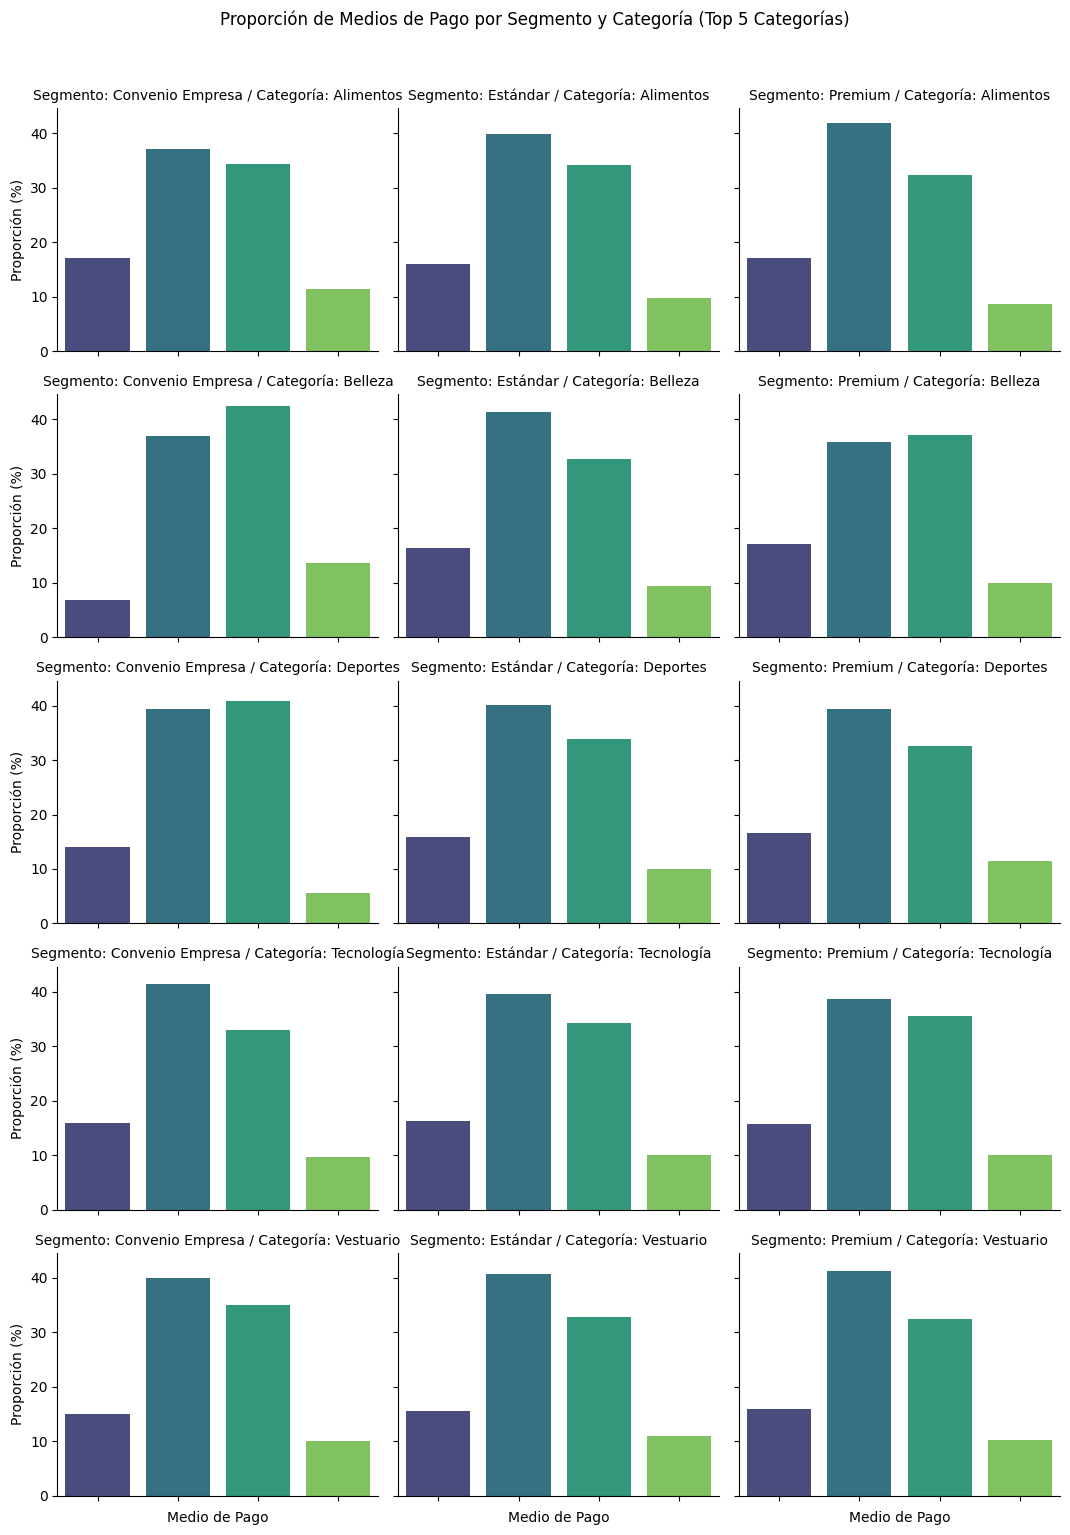

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupamos por segmento de cliente, categoría y medio de pago para obtener las proporciones
pago_segmento_categoria = df.groupby(['segmento_cliente', 'categoria', 'medio_pago']).size().unstack(fill_value=0)
pago_segmento_categoria = pago_segmento_categoria.apply(lambda x: x / x.sum(), axis=1) * 100

print("\n--- Proporción de Medios de Pago por Segmento de Cliente y Categoría (%): ---")
display(pago_segmento_categoria.head(10))

# Para visualizarlo, podemos usar un gráfico de barras apiladas o múltiples gráficos.
# Convertimos a formato 'largo' para seaborn
pago_segmento_categoria_melted = pago_segmento_categoria.reset_index().melt(id_vars=['segmento_cliente', 'categoria'],
                                                                         var_name='medio_pago',
                                                                         value_name='proporcion')

# Visualización (Visualización 6 de 7)
# Creamos un facet grid para ver la distribución por segmento y categoría
# Solo mostraremos las principales categorías para no saturar el gráfico.
# Seleccionar top N categorías si hay muchas
top_categorias = df['categoria'].value_counts().nlargest(5).index
df_filtered_categorias = pago_segmento_categoria_melted[pago_segmento_categoria_melted['categoria'].isin(top_categorias)]

g = sns.catplot(
    data=df_filtered_categorias,
    x='medio_pago',
    y='proporcion',
    col='segmento_cliente',
    row='categoria',
    kind='bar',
    height=3, aspect=1.2,
    palette='viridis',
    sharey=True
)
g.set_axis_labels("Medio de Pago", "Proporción (%)")
g.set_titles("Segmento: {col_name} / Categoría: {row_name}")
g.set_xticklabels(rotation=45, ha='right')
plt.suptitle('Proporción de Medios de Pago por Segmento y Categoría (Top 5 Categorías)', y=1.02)
plt.tight_layout()
plt.show()

## 4.3 Decisión final

- [x] Mantengo la hipótesis
- [ ] Modifico la hipótesis
- [ ] Descarto la hipótesis

**Explicación final:** El análisis de contraevidencia segmentando por categoría de producto no logró refutar la hipótesis inicial. Las preferencias de medios de pago para cada segmento de cliente (`segmento_cliente`) se mantuvieron consistentemente similares a través de las diversas `categoría`s de productos. Esto sugiere que las preferencias de pago están más ligadas a las características intrínsecas del segmento de cliente (como las demográficas y socioeconómicas o el tipo de relación que tienen con NovaMarket, por ejemplo, 'Convenio Empresa') que a la naturaleza específica del producto que están adquiriendo. La evidencia no muestra que la categoría de producto sea un factor significativo que altere la preferencia general de pago por segmento.

# 5. ¿Está este dataset listo para Machine Learning?

Supón que NovaMarket quiere entrenar posteriormente un modelo para predecir:

`devolucion`

**No debes entrenar ningún modelo.**

## 5.1 Tres riesgos que resolverías antes de modelar
1.  **Datos faltantes en `satisfaccion` (MNAR):** La alta proporción de nulos, especialmente en transacciones con `devolucion=1`, indica que la ausencia de datos no es aleatoria. Ignorar o imputar ingenuamente estos valores podría sesgar el modelo, haciéndolo subestimar la insatisfacción real, especialmente en escenarios de devolución.
2.  **Discrepancias en `monto_venta`:** El hecho de que el `monto_venta` registrado no siempre coincida con el `precio_unitario * cantidad * (1 - descuento_pct)` introduce un riesgo de utilizar una variable objetivo (o características relacionadas) incorrecta. Esto debe resolverse (ej. usando el monto calculado si es más fiable) para asegurar la integridad del target.
3.  **Colinealidad entre `canal` y `dias_entrega`:** Para transacciones en `Tienda`, `dias_entrega` es siempre 0, mientras que para 'Web' y 'App' toma valores mayores. Esto genera una fuerte dependencia entre ambas variables (`canal` y `dias_entrega`). Usarlas directamente podría introducir multicolinealidad, afectar la interpretabilidad del modelo o hacer que `dias_entrega` actúe como un proxy del canal, lo que podría no ser lo deseado. Se podría considerar crear una nueva característica que solo represente el tiempo de entrega real para canales no-tienda, o codificar `canal` y usar `dias_entrega` solo para transacciones relevantes.

## 5.2 Posible fuga de información
Identifica **una variable que no debería utilizarse** si contiene información que solo se conoce después de que ocurre la devolución.

**Variable:** `monto_reembolso`

**Por qué produciría data leakage:** Si `monto_reembolso` es mayor que cero, es una señal directa de que ha habido una devolución. Esta información solo está disponible *después* de que se produce la devolución. Si un modelo tuviera acceso a esta variable, podría predecir `devolucion` con una precisión casi perfecta, pero esta información no estaría disponible en el momento de la predicción en un escenario real (antes de que la devolución ocurra).

## 5.3 Dos decisiones antes de separar Train/Test
1.  **Estrategia de tratamiento de nulos en `satisfaccion`:** Dada la naturaleza MNAR de los nulos en `satisfaccion`, es crucial decidir una estrategia antes de la separación. Esto podría incluir la imputación con un valor especial (-1, o la mediana de su segmento/categoría si es apropiado), la creación de una categoría 'desconocida', o el uso de modelos que puedan manejar datos faltantes directamente. Esta decisión impactará el rendimiento y la interpretabilidad del modelo.
2.  **Partición de datos por tiempo (`fecha_hora`):** Dado que se trata de datos transaccionales con `fecha_hora`, la división de los datos en conjuntos de entrenamiento y prueba debe ser temporal (ej., todo el 2025-Q1 a 2025-Q3 para entrenamiento y 2025-Q4 para prueba). Una división aleatoria rompería la secuencia temporal y podría introducir fuga de información del futuro al pasado, llevando a un rendimiento engañosamente bueno en las métricas de validación.

In [25]:
# Evidencia adicional para 'Discrepancias en monto_venta'
print("--- Evidencia Adicional: Discrepancias en monto_venta ---")
# Recalculamos la diferencia por si el DF fue modificado en celdas anteriores
df['monto_calculado'] = (df['precio_unitario'] * df['cantidad']) * (1 - df['descuento_pct']/100)
df['diferencia_monto_recalc'] = df['monto_venta'] - df['monto_calculado']

discrepancy_count = df[df['diferencia_monto_recalc'].abs() > 0.01].shape[0] # Usando una pequeña tolerancia para flotantes
total_transactions = df.shape[0]
print(f"Número de transacciones con discrepancia en monto_venta: {discrepancy_count} ({discrepancy_count/total_transactions:.2%})\n")
print("Distribución de la diferencia (valores absolutos más frecuentes):")
display(df[df['diferencia_monto_recalc'].abs() > 0.01]['diferencia_monto_recalc'].value_counts().head())

--- Evidencia Adicional: Discrepancias en monto_venta ---
Número de transacciones con discrepancia en monto_venta: 13384 (53.54%)

Distribución de la diferencia (valores absolutos más frecuentes):


,count
diferencia_monto_recalc,
-0.2,757
0.4,735
0.2,674
0.2,672
-0.5,658


In [26]:
# Evidencia adicional para 'Fuga de información: monto_reembolso'
print("\n--- Evidencia Adicional: Fuga de Información por monto_reembolso ---")
# Verificar cuántas transacciones tienen monto_reembolso > 0 pero devolucion = 0
leakage_cases = df[(df['monto_reembolso'] > 0) & (df['devolucion'] == 0)]
print(f"Transacciones con monto_reembolso > 0 pero devolucion = 0: {leakage_cases.shape[0]}")
# Verificar cuántas transacciones tienen devolucion = 1 pero monto_reembolso = 0
no_reimbursement_devolutions = df[(df['monto_reembolso'] == 0) & (df['devolucion'] == 1)]
print(f"Transacciones con devolucion = 1 pero monto_reembolso = 0: {no_reimbursement_devolutions.shape[0]}\n")
# Mostrar una correlación simple entre estas variables
print(f"Correlación entre monto_reembolso y devolucion: {df['monto_reembolso'].corr(df['devolucion']):.4f}")


--- Evidencia Adicional: Fuga de Información por monto_reembolso ---
Transacciones con monto_reembolso > 0 pero devolucion = 0: 0
Transacciones con devolucion = 1 pero monto_reembolso = 0: 0

Correlación entre monto_reembolso y devolucion: 0.2717


In [27]:
# Evidencia adicional para 'Colinealidad entre canal y dias_entrega'
print("\n--- Evidencia Adicional: Relación entre canal y dias_entrega ---")
print("Distribución de dias_entrega por canal (en porcentaje):")
display(df.groupby('canal')['dias_entrega'].value_counts(normalize=True).unstack(fill_value=0).mul(100).round(2))
print("Promedio de días de entrega por canal:")
display(df.groupby('canal')['dias_entrega'].mean())


--- Evidencia Adicional: Relación entre canal y dias_entrega ---
Distribución de dias_entrega por canal (en porcentaje):


dias_entrega,0,1,2,3,4,5,6,7,8,9
canal,,,,,,,,,,
App,0.0,17.1,29.07,27.45,15.58,7.05,2.45,1.02,0.25,0.03
Tienda,100.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Web,0.0,9.7,21.98,27.35,20.25,12.26,5.51,1.88,0.74,0.32


Promedio de días de entrega por canal:


,dias_entrega
canal,
App,2.792840
Tienda,0.000000
Web,3.330901


# 6. Informe ejecutivo

Redacta un informe de **máximo 180 palabras** dirigido a la gerencia de NovaMarket.

Debe contener:
- los **3 hallazgos más importantes**;
- **2 acciones recomendadas**;
- **1 dato adicional** que pedirías antes de continuar con Machine Learning.

No describas código.

## Informe ejecutivo

**Informe Ejecutivo NovaMarket – Análisis de Datos (Pre-ML)**

Estimados gerentes,

Nuestro análisis de las transacciones de 2025 revela puntos clave para optimizar la estrategia antes de implementar Machine Learning.

**Hallazgos Principales:**
1.  **Discrepancia en montos de venta:** Más del 53% de las transacciones presentan inconsistencias entre el `monto_venta` registrado y el calculado, lo que impacta la fiabilidad de métricas clave.
2.  **Satisfacción sesgada:** Los datos faltantes de satisfacción no son aleatorios; un 40% de las devoluciones carecen de este dato, ocultando posibles problemas graves de servicio.
3.  **Preferencias de pago por segmento:** Los segmentos de clientes muestran claras preferencias de medios de pago, que se mantienen consistentes a través de las categorías de productos, sugiriendo oportunidades de marketing dirigido.

**Acciones Recomendadas:**
1.  **Auditoría de montos:** Urge revisar y corregir los procesos de registro de `monto_venta` para asegurar la integridad financiera.
2.  **Estrategia de captura de satisfacción:** Implementar métodos activos para recopilar feedback post-devolución, garantizando una visión completa de la experiencia del cliente.

**Dato Adicional Solicitado:** Necesitaríamos datos sobre la **razón específica de la devolución** para entender mejor el origen de la insatisfacción y la dinámica de las devoluciones.

# 7. Checklist antes de entregar

- [x] Ejecuté todas las celdas.
- [x] Los resultados quedan visibles.
- [x] No superé 7 visualizaciones.
- [x] Cada gráfico responde una pregunta.
- [x] No eliminé automáticamente valores extremos.
- [x] Respondí las cinco afirmaciones.
- [x] Incluí dos hallazgos propios.
- [x] Intenté refutar una de mis hipótesis.
- [x] Identifiqué riesgos antes del modelado.
- [x] Identifiqué una posible fuga de información.
- [x] El informe ejecutivo tiene máximo 180 palabras.


# Rúbrica de evaluación

| Criterio | Logrado | Parcialmente logrado | No logrado |
|---|---|---|---|
| **1. Preguntas y estrategia de exploración** | Formula preguntas pertinentes y orienta el análisis a comprobarlas. | Formula preguntas, pero son principalmente descriptivas o poco conectadas al análisis. | Ejecuta comandos sin una estrategia investigativa clara. |
| **2. Calidad y consistencia de los datos** | Detecta y argumenta problemas de calidad usando evidencia y distingue errores de fenómenos válidos. | Detecta problemas evidentes, pero los justifica parcialmente. | No identifica problemas relevantes o modifica datos sin investigarlos. |
| **3. Evaluación de las afirmaciones** | Evalúa las cinco afirmaciones con evidencia y segmentaciones apropiadas. | Evalúa las afirmaciones, pero parte del análisis es superficial o incompleto. | Las conclusiones se basan principalmente en opinión o evidencia insuficiente. |
| **4. Uso de métricas y visualizaciones** | Selecciona métricas y gráficos pertinentes y los interpreta correctamente. | Las técnicas son correctas, pero algunas son redundantes o poco pertinentes. | Predomina el EDA mecánico o la interpretación es incorrecta. |
| **5. Hallazgos propios y profundidad** | Encuentra dos hallazgos relevantes y profundiza uno buscando contraevidencia. | Los hallazgos son simples o la profundización es limitada. | No presenta hallazgos propios defendibles o no intenta contrastarlos. |
| **6. Preparación para Machine Learning** | Identifica riesgos relevantes, una fuga de información plausible y decisiones coherentes de preparación. | Identifica algunos riesgos, pero la conexión con el futuro modelo es parcial. | No reconoce riesgos importantes o confunde preparación de datos con modelado. |
| **7. Comunicación y reproducibilidad** | Notebook ordenado, ejecutable, con resultados visibles y conclusiones claras. | El notebook funciona parcialmente o la comunicación es irregular. | Notebook no reproducible, desordenado o sin conclusiones interpretables. |
